In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [57]:
df = pd.read_csv('iris.csv')
df.drop('Id',inplace = True, axis = 1)

X = df.iloc[:, : -1]
y = df.iloc[:, -1]

df.head().style.background_gradient(cmap = "mako")

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.100000,3.500000,1.400000,0.200000,Iris-setosa
1,4.900000,3.000000,1.400000,0.200000,Iris-setosa
2,4.700000,3.200000,1.300000,0.200000,Iris-setosa
3,4.600000,3.100000,1.500000,0.200000,Iris-setosa
4,5.000000,3.600000,1.400000,0.200000,Iris-setosa


In [58]:
fig = px.box(data_frame= df, x = 'Species', y = 'SepalLengthCm', color = 'Species', color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'], orientation='v')
fig.show()

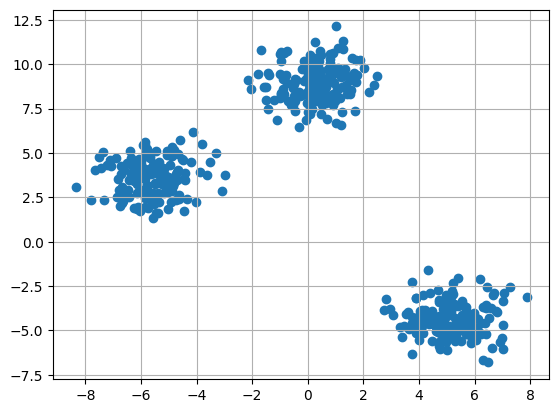

In [59]:
X, y = make_blobs(n_samples= 500, n_features= 2, centers=3, random_state=23)
fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [60]:
scaling = StandardScaler()
X = scaling.fit_transform(X)

k = 3
clusters = {}
np.random.seed(23)

for i in range(k):
    center = 2 * (2*np.random.random((X.shape[1],)) -1)
    points = []
    cluster = { 'center' : center, 'points' : []}
    clusters[i] = cluster
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

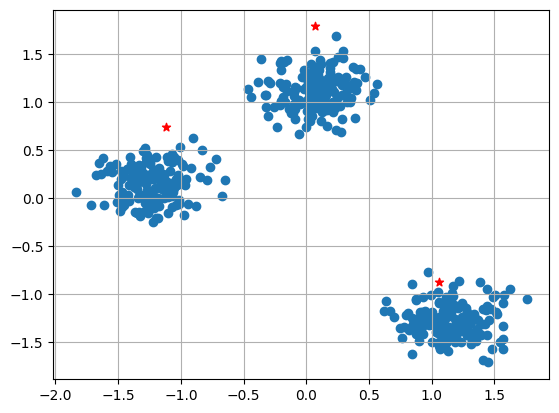

In [61]:
plt.scatter(X[:, 0], X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0], center[1], marker='*', c = 'red')
plt.show()

In [62]:
# Euclidean Distance
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))
# sqrt((x(i) - c(i))**2)

In [63]:
# UPDATE

def assigning_clusters(X, clusters):
    for c_i in range(k):
        clusters[c_i]['points']= []
    for i in range(X.shape[0]):
        dist = []
        current_x = X[i]
        for j in range(k):
            dis = distance(current_x, clusters[j]['center'])
            dist.append(dis)
        current_cluster = np.argmin(dist)
        clusters[current_cluster]['points'].append(current_x)
    return clusters

def updating_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            center_new = points.mean(axis = 0)
            clusters[i]['center'] = center_new
            clusters[i]['points'] = []
    return clusters

In [64]:
# predict the Cluster
def predict_clusters(X, clusters):
    predicts = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i], clusters[j]['center']))
        predicts.append(np.argmin(dist))
    return predicts

In [68]:
max_iter = 100
for i in range(max_iter):
    old_center = [clusters[j]['center'].copy() for j in range(k)]
    clusters = assigning_clusters(X, clusters)
    clusters = updating_clusters(X, clusters)
    new_center = [clusters[j]['center'] for j in range(k)]
    if np.allclose(old_center, new_center):
        break
predicts = predict_clusters(X, clusters)

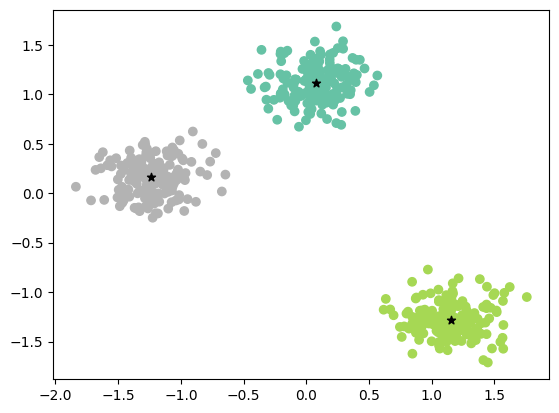

In [69]:
plt.scatter(X[:,0], X[:,1], c = predicts, cmap='Set2')
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0], center[1], marker='*', color = 'black')
plt.show()